In [30]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

🔵 LOAD ALL DFS (FEATURES AND CLINICAL BIOMARKERS)

In [47]:
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

pd.set_option('future.no_silent_downcasting', True)
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1,'Stage 2': 2,'Stage 3': 3})
clinical_df = clinical_df.dropna(subset=['Stage'])
clinical_df['Stage'] = clinical_df['Stage'].astype(int)

df_c25 = pd.read_csv(r"D:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
df_vmi40 = pd.read_csv(r"D:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
df_vmi80 = pd.read_csv(r"D:\CSV\merged\merged_monoe_80kev_radiomics_spine_lesions_features.csv")
df_vmi120 = pd.read_csv(r"D:\CSV\merged\merged_monoe_120kev_radiomics_spine_lesions_features.csv")
df_konv = pd.read_csv(r"D:\CSV\merged\merged_konv_radiomics_spine_lesions_features.csv")

🔵 TRAIN AND TEST MODEL BASED ON IMAGE FEATURES FOR EVERY DF

Accuracy: 0.714


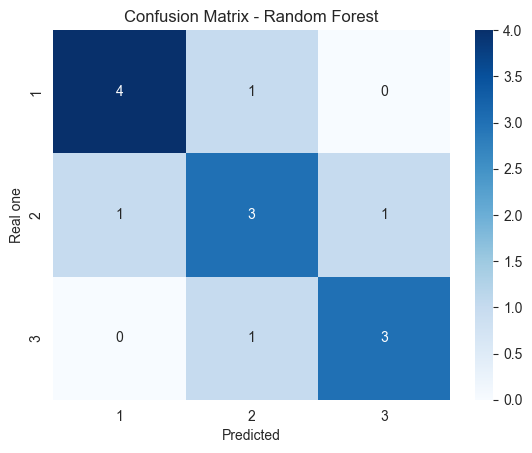

In [48]:
df = df_c25
X = df.select_dtypes(include=['number'])
y = clinical_df['Stage']

valid_idx = X.notna().all(axis=1) & y.notna()
X = X[valid_idx]
y = y[valid_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1,2,3], yticklabels=[1,2,3])
plt.xlabel("Predicted")
plt.ylabel("Real one")
plt.title(f"Confusion Matrix - Random Forest")
plt.show()

Accuracy for df: CaSupp_25: 0.714

Feature importance
gradient_firstorder_10Percentile                   0.021111
gradient_glcm_Imc1                                 0.018979
original_firstorder_Skewness                       0.017292
original_glcm_ClusterShade                         0.015644
original_firstorder_MeanAbsoluteDeviation          0.015197
original_firstorder_Kurtosis                       0.013145
original_glszm_GrayLevelNonUniformityNormalized    0.012804
original_firstorder_10Percentile                   0.012527
original_firstorder_RobustMeanAbsoluteDeviation    0.012138
original_firstorder_Variance                       0.011705
dtype: float64


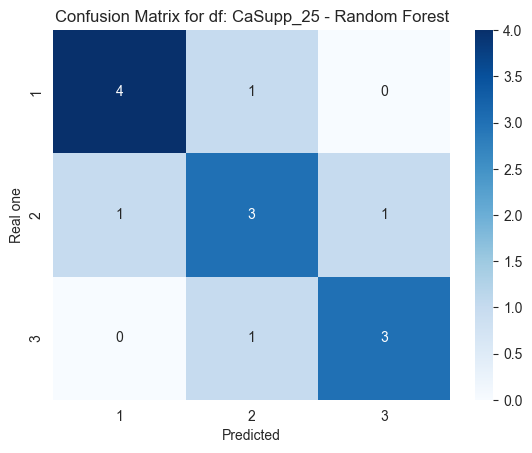

Accuracy for df: Konv: 0.500

Feature importance
original_gldm_LargeDependenceEmphasis                0.014303
original_glrlm_LongRunEmphasis                       0.013480
original_glrlm_RunPercentage                         0.013268
gradient_glrlm_LongRunLowGrayLevelEmphasis           0.013147
gradient_firstorder_10Percentile                     0.012683
gradient_glszm_SmallAreaLowGrayLevelEmphasis         0.011994
gradient_glrlm_RunPercentage                         0.011974
gradient_gldm_SmallDependenceLowGrayLevelEmphasis    0.011588
gradient_gldm_LargeDependenceEmphasis                0.011477
gradient_glrlm_LongRunEmphasis                       0.011420
dtype: float64


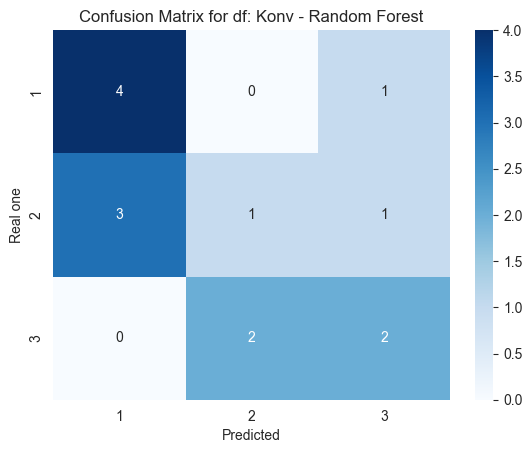

Accuracy for df: VMI_40: 0.714

Feature importance
original_glrlm_ShortRunEmphasis                0.019338
gradient_glcm_ClusterShade                     0.017333
original_firstorder_Kurtosis                   0.016262
gradient_glrlm_ShortRunLowGrayLevelEmphasis    0.015726
original_glrlm_LongRunEmphasis                 0.014052
gradient_glcm_ClusterProminence                0.013666
gradient_glcm_Imc2                             0.013584
original_firstorder_Skewness                   0.012521
original_glcm_Idm                              0.011591
gradient_glcm_ClusterTendency                  0.011326
dtype: float64


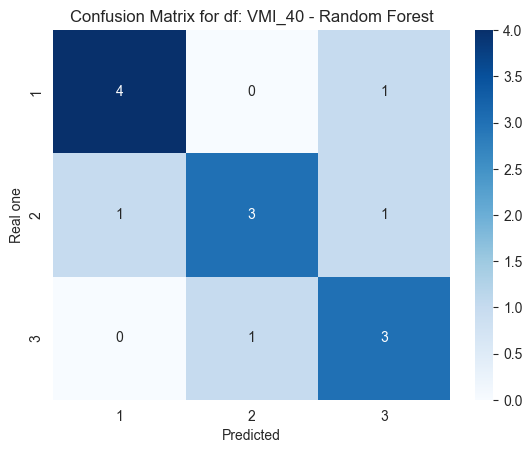

Accuracy for df: VMI_80: 0.714

Feature importance
gradient_firstorder_10Percentile                     0.016674
gradient_glcm_ClusterShade                           0.015084
gradient_gldm_LargeDependenceLowGrayLevelEmphasis    0.014059
original_glrlm_RunPercentage                         0.012263
original_glrlm_RunVariance                           0.010933
original_shape_LeastAxisLength                       0.010895
original_glcm_Idn                                    0.010850
gradient_glrlm_RunPercentage                         0.010828
gradient_glszm_ZoneEntropy                           0.010726
gradient_gldm_GrayLevelVariance                      0.010496
dtype: float64


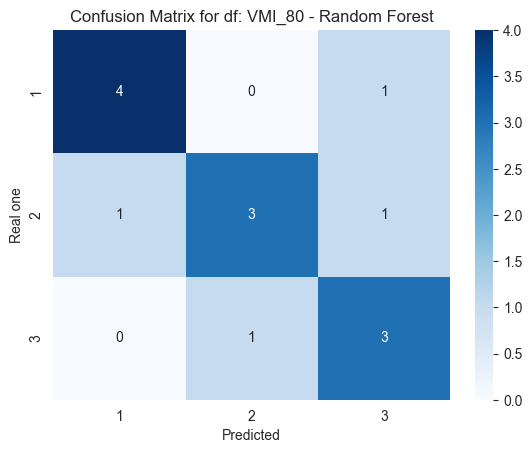

Accuracy for df: VMI_120: 0.571

Feature importance
gradient_glrlm_RunPercentage                         0.017110
gradient_glcm_ClusterShade                           0.015278
original_gldm_DependenceVariance                     0.014293
original_glcm_Idmn                                   0.013199
gradient_firstorder_10Percentile                     0.012954
gradient_glcm_ClusterProminence                      0.012757
gradient_gldm_LargeDependenceLowGrayLevelEmphasis    0.012717
original_shape_LeastAxisLength                       0.012113
gradient_glcm_ClusterTendency                        0.010968
gradient_glcm_Correlation                            0.010681
dtype: float64


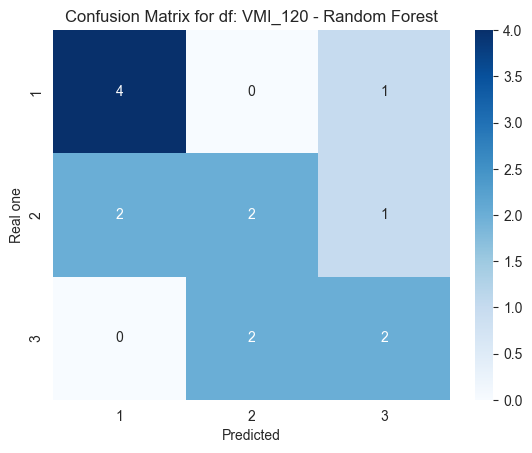

In [50]:
dfs = [df_c25, df_konv, df_vmi40, df_vmi80, df_vmi120]
dataset_names = ['CaSupp_25', 'Konv', 'VMI_40', 'VMI_80', 'VMI_120']

for df, name in zip(dfs, dataset_names):

    X = df.select_dtypes(include=['number'])
    y = clinical_df['Stage']

    valid_idx = X.notna().all(axis=1) & y.notna()
    X = X[valid_idx]
    y = y[valid_idx]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy for df: {name}: {acc:.3f}")
    print()
    print("Feature importance")
    feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
    feature_importance = feature_importance.sort_values(ascending=False)
    print(feature_importance.head(10))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1,2,3], yticklabels=[1,2,3])
    plt.xlabel("Predicted")
    plt.ylabel("Real one")
    plt.title(f"Confusion Matrix for df: {name} - Random Forest")
    plt.show()

🔵 TRAIN AND TEST MODEL BASED JUST ON CLINICAL BIOMARKER

Accuracy: 1.000


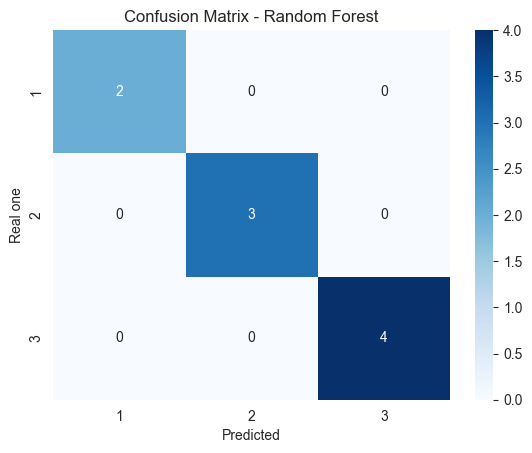

In [51]:
X = clinical_df.select_dtypes(include=['number']).drop(columns='Stage')
y = clinical_df['Stage']

valid_idx = X.notna().all(axis=1) & y.notna()
X = X[valid_idx]
y = y[valid_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1,2,3], yticklabels=[1,2,3])
plt.xlabel("Predicted")
plt.ylabel("Real one")
plt.title(f"Confusion Matrix - Random Forest")
plt.show()

🔵 IMPORTANCE OF FEATURES FROM RANDOM FOREST MODEL

In [52]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)
feature_importance

Beta2 microglobulin (mg/l)          0.425441
Creatinine level (µmol/l)           0.138436
Calcium total level (mmol/l)        0.088341
Serum kappa FLC quantity (mg/l      0.083309
Plasmocyte count FC (%)             0.067146
Serum M-protein quantity (g/l)      0.060407
IgA quantity (g/l)                  0.052786
IgM quantity (g/l)                  0.045965
Serum lambda FLC quantity (mg/l)    0.019464
IgG quantity (g/l)                  0.018705
dtype: float64

🔵 RANDOM FOREST USING SELECTED FEATURES FROM K-W test (at least 2 significant result from 3 pairs)

In [53]:
kw_c25 = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_CaSupp_25.csv")
kw_konv = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_konv.csv")
kw_vmi40 = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_vmi40.csv")
kw_vmi80 = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_vmi80.csv")
kw_vmi120 = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_vmi120.csv")

significant_c25 = kw_c25[(kw_c25[['p(1-2)', 'p(1-3)', 'p(2-3)']] < 0.05).sum(axis=1) >= 2]['Feature']
significant_konv = kw_konv[(kw_konv[['p(1-2)', 'p(1-3)', 'p(2-3)']] < 0.05).sum(axis=1) >= 2]['Feature']
significant_vmi40 = kw_vmi40[(kw_vmi40[['p(1-2)', 'p(1-3)', 'p(2-3)']] < 0.05).sum(axis=1) >= 2]['Feature']
significant_vmi80 = kw_vmi80[(kw_vmi80[['p(1-2)', 'p(1-3)', 'p(2-3)']] < 0.05).sum(axis=1) >= 2]['Feature']
significant_vmi120 = kw_vmi120[(kw_vmi120[['p(1-2)', 'p(1-3)', 'p(2-3)']] < 0.05).sum(axis=1) >= 2]['Feature']

Accuracy for df: CaSupp_25 with significant features based on K-W test: 0.714

Feature importance
gradient_firstorder_10Percentile              0.036457
gradient_glcm_Imc1                            0.028572
original_glcm_ClusterTendency                 0.021052
gradient_glrlm_LongRunLowGrayLevelEmphasis    0.019484
gradient_glcm_Imc2                            0.019271
original_glcm_Id                              0.018953
gradient_glrlm_RunEntropy                     0.018060
original_firstorder_RootMeanSquared           0.017771
original_glcm_MaximumProbability              0.017215
original_glcm_ClusterShade                    0.016889
dtype: float64


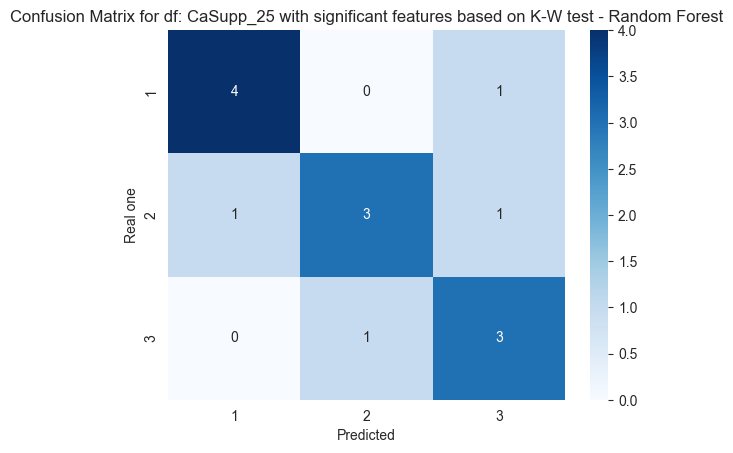

Accuracy for df: Konv with significant features based on K-W test: 0.571

Feature importance
gradient_glrlm_LongRunLowGrayLevelEmphasis         0.027609
gradient_gldm_LowGrayLevelEmphasis                 0.025748
gradient_firstorder_10Percentile                   0.023807
original_gldm_LargeDependenceEmphasis              0.022861
gradient_gldm_DependenceVariance                   0.020767
gradient_glcm_ClusterShade                         0.019760
original_glrlm_LongRunEmphasis                     0.018755
gradient_glrlm_RunLengthNonUniformityNormalized    0.018157
gradient_gldm_LargeDependenceEmphasis              0.016277
gradient_glcm_Imc1                                 0.016191
dtype: float64


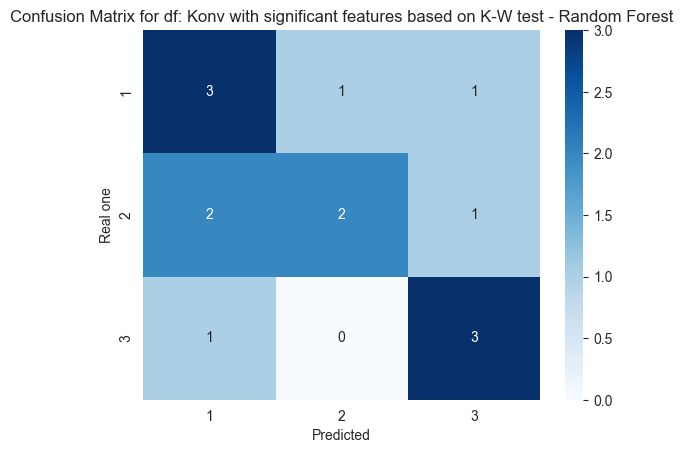

Accuracy for df: VMI_40 with significant features based on K-W test: 0.714

Feature importance
original_firstorder_Kurtosis                   0.035701
original_firstorder_Skewness                   0.023902
gradient_glrlm_GrayLevelVariance               0.022679
gradient_glcm_Imc2                             0.022607
original_glrlm_ShortRunEmphasis                0.021873
original_gldm_DependenceVariance               0.019498
gradient_glcm_DifferenceVariance               0.016938
gradient_glrlm_ShortRunLowGrayLevelEmphasis    0.016855
gradient_glcm_Imc1                             0.016562
gradient_glcm_ClusterShade                     0.016319
dtype: float64


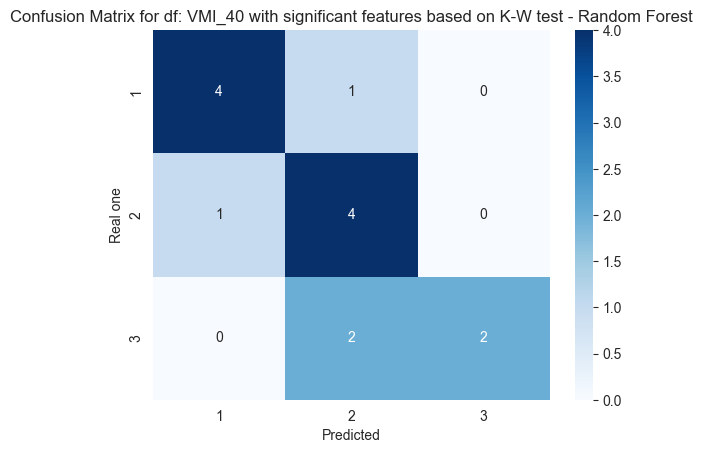

Accuracy for df: VMI_80 with significant features based on K-W test: 0.786

Feature importance
gradient_firstorder_10Percentile                     0.022930
gradient_glcm_ClusterShade                           0.022455
gradient_glszm_GrayLevelVariance                     0.021284
gradient_glcm_ClusterProminence                      0.020910
gradient_gldm_LargeDependenceLowGrayLevelEmphasis    0.020289
gradient_glrlm_LongRunLowGrayLevelEmphasis           0.019440
gradient_glrlm_GrayLevelVariance                     0.018142
original_glszm_ZoneEntropy                           0.017940
gradient_gldm_LargeDependenceEmphasis                0.017469
original_firstorder_Kurtosis                         0.017220
dtype: float64


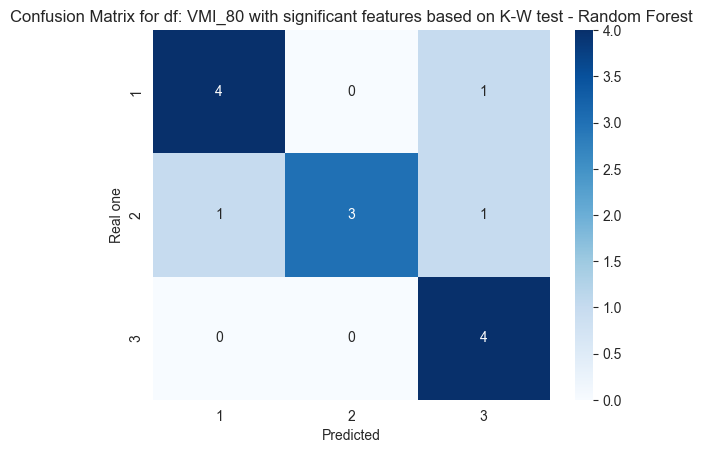

Accuracy for df: VMI_120 with significant features based on K-W test: 0.714

Feature importance
original_gldm_DependenceVariance                     0.028381
gradient_glcm_ClusterShade                           0.025435
gradient_glrlm_LongRunLowGrayLevelEmphasis           0.023058
gradient_glcm_ClusterProminence                      0.018906
gradient_glszm_GrayLevelNonUniformityNormalized      0.018859
gradient_gldm_LargeDependenceLowGrayLevelEmphasis    0.018463
gradient_glszm_GrayLevelVariance                     0.018132
gradient_firstorder_10Percentile                     0.018067
gradient_gldm_DependenceNonUniformityNormalized      0.016691
gradient_ngtdm_Complexity                            0.016458
dtype: float64


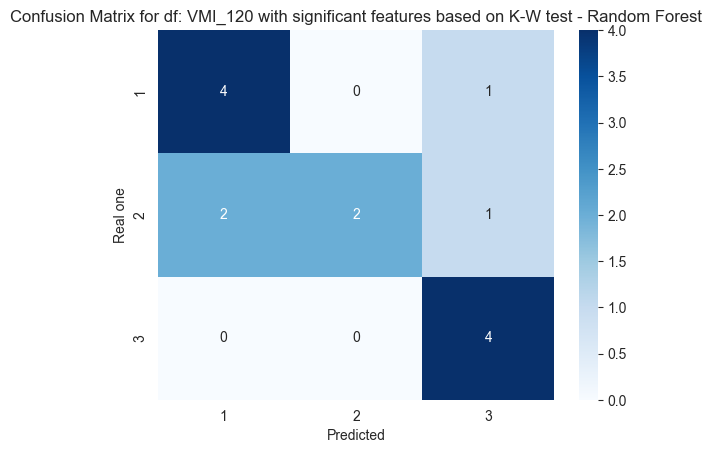

In [54]:
dfs = [df_c25, df_konv, df_vmi40, df_vmi80, df_vmi120]
dataset_names = ['CaSupp_25', 'Konv', 'VMI_40', 'VMI_80', 'VMI_120']
significant = [significant_c25, significant_konv, significant_vmi40, significant_vmi80, significant_vmi120]

for df, name, significant_features in zip(dfs, dataset_names, significant):

    X = df[significant_features].select_dtypes(include=['number'])
    y = clinical_df['Stage']

    valid_idx = X.notna().all(axis=1) & y.notna()
    X = X[valid_idx]
    y = y[valid_idx]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy for df: {name} with significant features based on K-W test: {acc:.3f}")
    print()
    print("Feature importance")
    feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
    feature_importance = feature_importance.sort_values(ascending=False)
    print(feature_importance.head(10))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1,2,3], yticklabels=[1,2,3])
    plt.xlabel("Predicted")
    plt.ylabel("Real one")
    plt.title(f"Confusion Matrix for df: {name} with significant features based on K-W test - Random Forest")
    plt.show()